<h1>ВТОРАЯ ПРАКТИЧЕСКАЯ!!!!!!!!!!!!!!!!!!!!!!!!!!!!!</h1>

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dir = 'training'
val_dir = 'validation'
test_dir = 'evaluation'

# Аугментации и препроцессинг
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# Готовим датасеты
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

# DataLoader'ы
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)


In [5]:
from tensorflow.keras.utils import Sequence
import numpy as np

class PytorchToKerasSequence(Sequence):
    def __init__(self, dataloader):
        self.loader = list(dataloader)  # фиксируем данные в память
    
    def __len__(self):
        return len(self.loader)

    def __getitem__(self, idx):
        x, y = self.loader[idx]
        x = x.permute(0, 2, 3, 1).numpy()
        y = y.numpy()
        return x, y


In [7]:
train_gen = PytorchToKerasSequence(train_loader)
val_gen = PytorchToKerasSequence(val_loader)
test_gen = PytorchToKerasSequence(test_loader)


food - 0, nonfood - 1 

In [22]:
from collections import Counter

print(Counter(train_dataset.targets))
print(Counter(val_dataset.targets))
print(Counter(test_dataset.targets))

Counter({0: 1500, 1: 1500})
Counter({0: 500, 1: 500})
Counter({0: 500, 1: 500})


Все мегахорошо сбалансировано

<h4>возьмем несколько архитектур</h4>

Сначала создадим свою

In [59]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras_tuner import HyperModel

class FoodClassifierHyperModel(HyperModel):
    def build(self, hp):
        model = keras.Sequential()

        # Входной сверточный слой
        model.add(layers.Input(shape=(128, 128, 3)))

        # Следующие сверточные слои (от 2 до 5)
        for i in range(hp.Int("conv_blocks", 2, 4)):
            # Сверточный слой
            filters = hp.Int(f"filters_{i}", min_value=32, max_value=128, step=32)
            model.add(layers.Conv2D(filters, kernel_size=3, padding="same"))
            # Слой батч нормализации
            if hp.Boolean(f"batch_norm_{i}"):
                model.add(layers.BatchNormalization())
            # Слой активации
            model.add(layers.Activation("relu"))
            # Слой пулинга
            model.add(layers.MaxPooling2D())
            # Слой дропаута
            dropout_rate = hp.Float(f"dropout_{i}", min_value=0.0, max_value=0.5, step=0.1)
            if dropout_rate > 0.0:
                model.add(layers.Dropout(dropout_rate))

                      

        # Добавляем флатенизацию
        model.add(layers.Flatten())

        # Классификатор
        for j in range(hp.Int("dense_layers", 1, 2)):
            units = hp.Int(f"dense_units_{j}", min_value=128, max_value=512, step=64)
            model.add(layers.Dense(units, activation="relu"))
            model.add(layers.Dropout(rate=hp.Float(f"dropout_{j}", min_value=0.3, max_value=0.7, step=0.1)))

        
        model.add(layers.Dense(1, activation="sigmoid"))

        
        model.compile(
            optimizer=keras.optimizers.Adam(
                hp.Float("learning_rate", 1e-4, 1e-2, sampling="log")
            ),
            loss="binary_crossentropy",
            metrics=["accuracy"],
        )
        return model


In [61]:
from keras_tuner.tuners import RandomSearch

# ⚙️ Настройка тюнера
hypermodel = FoodClassifierHyperModel()

tuner = RandomSearch(
    hypermodel,
    objective="val_accuracy",
    max_trials=20,
    executions_per_trial=1,
    directory="food_classifier_tuning",
    project_name="cnn_food_binary"
)


tuner.search(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    steps_per_epoch=len(train_loader),
    validation_steps=len(val_loader)
)


Reloading Tuner from food_classifier_tuning\cnn_food_binary\tuner0.json

Search: Running Trial #17

Value             |Best Value So Far |Hyperparameter
4                 |4                 |conv_blocks
128               |64                |filters_0
True              |True              |batch_norm_0
128               |64                |filters_1
True              |False             |batch_norm_1
2                 |1                 |dense_layers
128               |384               |dense_units_0
0.5               |0.3               |dropout_0
0.0068936         |0.00037144        |learning_rate
320               |128               |dense_units_1
0.5               |0.3               |dropout_1
32                |128               |filters_2
False             |True              |batch_norm_2
96                |64                |filters_3
False             |True              |batch_norm_3
0.4               |0.2               |dropout_2
0.3               |0                 |dropout_3

E

KeyboardInterrupt: 

In [62]:
best_models = tuner.get_best_models(num_models=3)  
for model in best_models:
    model.summary()  


C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128, 128, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 384)                 │       1,573,2

 Total params: 1,761,025 (6.72 MB)

 Trainable params: 1,760,513 (6.72 MB)

...

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 128)       │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 128)       │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128, 128, 128)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 32)          │          36,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,148,161 (8.19 MB)

 Trainable params: 2,147,777 (8.19 MB)

 Non-trainable params: 384 (1.50 KB)

In [63]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128, 128, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 384)                 │       1,573,2

 Total params: 1,761,025 (6.72 MB)

 Trainable params: 1,760,513 (6.72 MB)

 Non-trainable params: 512 (2.00 KB)

In [64]:
loss, accuracy = best_model.evaluate(test_gen)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 235ms/step - accuracy: 0.8968 - loss: 0.2526
Loss: 0.2584
Accuracy: 0.9040


<h3>MobileNet</h3>

In [18]:
from keras import layers, models
from keras.applications import MobileNetV2
from keras_tuner import HyperModel

class ResNetHyperModel(HyperModel):
    def __init__(self, input_shape, num_classes):
        self.input_shape = input_shape
        self.num_classes = num_classes

    def build(self, hp):
        base_model = MobileNetV2(
            include_top=False,
            weights=None,
            input_shape=self.input_shape,
            pooling="avg"  # берём глобальный AveragePooling в конце
        )

        model = models.Sequential()
        model.add(base_model)

        num_dense_layers = hp.Int("dense_layers", 1, 3)

        for i in range(num_dense_layers):
            units = hp.Int(f"dense_units_{i}", min_value=64, max_value=512, step=64)
            model.add(layers.Dense(units, activation="relu"))

            # Можно ещё сюда дропаут загнать
            dropout_rate = hp.Float(f"dropout_rate_{i}", 0.0, 0.5, step=0.1)
            if dropout_rate > 0.0:
                model.add(layers.Dropout(dropout_rate))

        model.add(layers.Dense(self.num_classes, activation="softmax"))

        model.compile(
            optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        return model


In [25]:
from keras_tuner.tuners import RandomSearch

hypermodel = ResNetHyperModel(input_shape=(128, 128, 3), num_classes=2)

tuner = RandomSearch(
    hypermodel,
    objective="val_accuracy",
    max_trials=10,
    executions_per_trial=1,
    directory="resnet_tuning",
    project_name="resnet_classifier"
)

tuner.search(train_gen, validation_data=val_gen, epochs=10)


Reloading Tuner from resnet_tuning\resnet_classifier\tuner0.json

Search: Running Trial #8

Value             |Best Value So Far |Hyperparameter
2                 |2                 |dense_layers
384               |320               |dense_units_0
0.4               |0.1               |dropout_rate_0
128               |128               |dense_units_1
0.2               |0.1               |dropout_rate_1
384               |None              |dense_units_2
0                 |None              |dropout_rate_2

Epoch 1/10


KeyboardInterrupt: 

Больше не буду подбирать верхушку 🤧, остановил после 7 трейла, слишком долго обучается

In [26]:
best_model_mobilenet = tuner.get_best_models(num_models=1)[0]
best_model_mobilenet.summary()

C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 326 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 1280)                │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 320)                 │         409,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 320)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          41,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,709,250 (10.33 MB)

 Trainable params: 2,675,138 (10.20 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [27]:
loss, accuracy = best_model_mobilenet.evaluate(test_gen)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 221ms/step - accuracy: 0.8206 - loss: 0.6781
Loss: 0.6934
Accuracy: 0.5000


Вот тут я что-то не понял, у меня акураси во время обучения была около 0.95 на разных трейлах, а сейчас почему то 0.5

<h4>Короче, попробуем без подбора керас тюнером верхушки обучить</h4>

In [47]:
from keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(128, 128, 3),  
    include_top=False,          
    weights=None                
)

In [48]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)  
x = layers.Dense(128, activation='relu')(x)  
x = layers.Dropout(0.3)(x)                   
outputs = layers.Dense(1, activation='sigmoid')(x)  


In [49]:
model_mobilenet = keras.Model(inputs=base_model.input, outputs=outputs)

model_mobilenet.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [50]:
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 64, 64, 32)        │             864 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 64, 64, 32)        │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 64, 64, 32)        │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 64, 64, 32)        │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 64, 64, 32)        │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 64, 64, 32)        │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 64, 64, 16)        │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 64, 64, 16)        │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 64, 64, 96)        │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 64, 64, 96)        │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 64, 64, 96)        │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 65, 65, 96)        │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 32, 32, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 7,198,021 (27.46 MB)

 Trainable params: 2,387,969 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

 Optimizer params: 4,775,940 (18.22 MB)

In [51]:
history = model_mobilenet.fit(
    train_gen,               
    validation_data=val_gen, 
    epochs=10
)


Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.6655 - loss: 0.6650 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.8435 - loss: 0.3595 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.8877 - loss: 0.2812 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.9014 - loss: 0.2459 - val_accuracy: 0.5000 - val_loss: 0.6979
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.9140 - loss: 0.2095 - val_accuracy: 0.5000 - val_loss: 0.7007
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9272 - loss: 0.2073 - val_accuracy: 0.5000 - val_loss: 0.7077
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.9450 - loss: 0.1472 - val_accuracy: 0.5000 - val_loss: 0.7114
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9390 - loss: 0.1479 - val_accuracy: 0.5000 - v

In [52]:
loss, accuracy = model_mobilenet.evaluate(test_gen)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 259ms/step - accuracy: 0.8206 - loss: 0.5319
Loss: 0.7498
Accuracy: 0.5000


Я ничего не понимаю

<h3>EfficientNet </h3>

In [53]:
from tensorflow.keras.applications import EfficientNetB0
base_model = EfficientNetB0(
    include_top=False,         
    weights=None,              
    input_shape=(128, 128, 3)  
)

In [54]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)  
x = layers.Dense(128, activation='relu')(x) 
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation='sigmoid')(x) 

model_effnet = models.Model(inputs=base_model.input, outputs=output)


In [55]:
model_effnet.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [56]:
history = model_effnet.fit(
    train_gen,              
    validation_data=val_gen,
    epochs=10               
)


Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.6255 - loss: 0.7078 - val_accuracy: 0.5000 - val_loss: 0.7063
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.8322 - loss: 0.4064 - val_accuracy: 0.5000 - val_loss: 0.8268
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.8759 - loss: 0.3203 - val_accuracy: 0.5000 - val_loss: 0.8764
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.9272 - loss: 0.2149 - val_accuracy: 0.5000 - val_loss: 0.7084
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.9429 - loss: 0.1566 - val_accuracy: 0.5080 - val_loss: 0.7049
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.9522 - loss: 0.1590 - val_accuracy: 0.5600 - val_loss: 0.8553
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.9541 - loss: 0.1229 - val_accuracy: 0.6150 - val_loss: 1.2824
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.9725 - loss: 0.0841 - val_accuracy: 0.8400 - v

Почему акураси на валидации на первых эпохах равна ровно 0.5?

Чтош, тут без подбора классификатора, как видим, лучшая accuracy равна 0.87, это похуже, чем когда мы делали свою модель

In [57]:

model_effnet.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)    │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 128, 128, 3)       │               0 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization_1               │ (None, 128, 128, 3)       │               7 │ rescaling_1[0][0]          │
│ (Normalization)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 129, 129, 3)       │               0 │ normalization_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 64, 64, 32)        │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 64, 64, 32)        │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 64, 64, 32)        │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 64, 64, 32)        │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 64, 64, 32)        │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 64, 64, 32)        │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_excite (Multiply)  │ (None, 64, 64, 32)        │               

 Total params: 12,556,960 (47.90 MB)

 Trainable params: 4,171,645 (15.91 MB)

 Non-trainable params: 42,023 (164.16 KB)

 Optimizer params: 8,343,292 (31.83 MB)

In [58]:
loss, accuracy = model_effnet.evaluate(test_gen)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 310ms/step - accuracy: 0.8129 - loss: 0.7121
Loss: 0.7708
Accuracy: 0.8050


Итого:<br>
accuracy<br>
наша модель - 0.9040<br>
mobile net - 0.5<br>
efficient net - 0.8050

<h2>VGG16</h2>

In [6]:
from tensorflow.keras.applications import VGG16

In [11]:
from keras import layers, models

Сделаем новые генераторы размера 224 на 224

In [7]:
train_dir = 'training'
val_dir = 'validation'
test_dir = 'evaluation'

# Аугментации и препроцессинг
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Готовим датасеты
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

# DataLoader'ы
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)


In [8]:
train_gen = PytorchToKerasSequence(train_loader)
val_gen = PytorchToKerasSequence(val_loader)
test_gen = PytorchToKerasSequence(test_loader)

In [9]:
model_vgg16 = VGG16(
    input_shape=(224, 224, 3),
    include_top=True,      
    weights='imagenet'
)

In [12]:
x = model_vgg16.layers[-2].output 
output = layers.Dense(1, activation='sigmoid')(x)
model_vgg16 = models.Model(inputs=model_vgg16.input, outputs=output)


In [13]:
for layer in model_vgg16.layers:
    if isinstance(layer, layers.Conv2D) or isinstance(layer, layers.MaxPooling2D):
        layer.trainable = False
    else:
        layer.trainable = True


In [14]:
for layer in model_vgg16.layers:
    if isinstance(layer, layers.Dense):
        layer.set_weights([
            tf.random.normal(shape=w.shape) * 0.05 for w in layer.get_weights()
        ])


In [15]:
model_vgg16.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [16]:
history = model_vgg16.fit(
    train_gen,              # твой тренировочный генератор
    validation_data=val_gen, # валидация
    epochs=10               # сколько эпох хочешь
)


C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1255s 13s/step - accuracy: 0.7286 - loss: 39.4545 - val_accuracy: 0.9480 - val_loss: 0.1557
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1244s 13s/step - accuracy: 0.9418 - loss: 0.2258 - val_accuracy: 0.9400 - val_loss: 0.1708
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1251s 13s/step - accuracy: 0.9820 - loss: 0.0474 - val_accuracy: 0.9560 - val_loss: 0.1750
Epoch 4/10
39/94 ━━━━━━━━━━━━━━━━━━━━ 9:30 10s/step - accuracy: 0.9877 - loss: 0.0281

KeyboardInterrupt: 

In [ ]:
test_loss, test_acc = model_vgg16.evaluate(test_gen)  # или (X_test, y_test) если без генератора
print(f"Точность на тесте: {test_acc:.2f}")


модель слишком долго обучается, я остановил ее, но как можем видеть, из-за ее глубины, точность только на 4 эпохе обучения выше, чем на какой либо другой модели

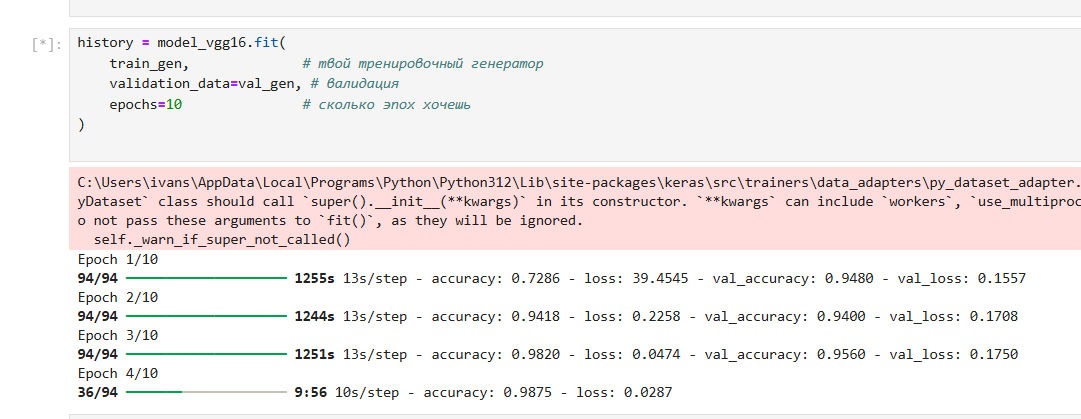